# From satellite data to disease risk maps

A practical introduction to species distribution modeling

Veronica Andreo  
2026-05-21

# Setup

## Open this notebook in Colab

To open this notebook in Colab, just use the [repository
URL](https://github.com/veroandreo/pavia-2026) as shown below:

**include img here**

## Mount your GDrive in Colab

In [1]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

## Get the data and unzip in your GDrive

In [2]:
# Download zip directly into your Drive
import gdown, os

dest = '/content/drive/MyDrive/pavia_2026'
os.makedirs(dest, exist_ok=True)

file_id = '1tBmsMtivpkKdV6l9OyytUgWK-FnUy92Q'
gdown.download(id=file_id, output=f'{dest}/pavia_2026.zip', quiet=False)

In [3]:
# Unzip within the pavia_2026 folder
import zipfile

if not os.path.exists(f'{dest}/eu_laea'):
    with zipfile.ZipFile(f'{dest}/pavia_2026.zip', 'r') as z:
        z.extractall(dest)
    print("Done")
else:
    print("Already unzipped, skipping")

The folder structure within your `pavia_2026` folderz should look like:

    .
    ├── aedes_albopictus.gpkg
    └── eu_laea
        ├── italy_LST_daily
        └── PERMANENT

To check, just click the folder icon on the left sidebar, navigate to
drive → MyDrive → pavia_2026 and check that you can see eu_laea/ and
aedes_albopictus.gpkg.

## Install GRASS in Google Colab

Install GRASS from the `ppa:ubuntugis/ubuntugis-unstable` repository.
This may take some minutes.

In [4]:
%%capture
# Install GRASS and Java
apt-get update -q
add-apt-repository -y ppa:ubuntugis/ubuntugis-unstable
apt-get install -q grass grass-dev default-jdk

In [5]:
# Check the GRASS GIS installation
import subprocess
print(subprocess.check_output(["grass", "--config", "version"], text=True))

## Configure the GRASS Python environment

Tell Python where to find GRASS packages and import the required
libraries:

-   **`grass.script`** (`gs`): project and session management, tools
    execution
-   **`grass.jupyter`** (`gj`): interactive map visualisation in
    notebooks

In [6]:
import sys

# Add GRASS Python packages to path
grass_python_path = subprocess.check_output(
    ["grass", "--config", "python_path"], text=True
).strip()
sys.path.append(grass_python_path)
print(f"GRASS Python path: {grass_python_path}")

In [7]:
import grass.script as gs
import grass.jupyter as gj

print("grass.script and grass.jupyter imported successfully")

We are set!

# What kind of GRASS are we talking about?

> **New to GRASS? Read the basics first**
>
> Not familiar with GRASS? The [GRASS 101](notebook-01.html) page covers
> its engine model, interfaces, project structure, tools, and temporal
> framework — everything you need to follow this notebook.

# Hands-on!

## Temporal data processing

In this section we’ll go through the processing of MODIS LST daily time
series data to derive relevant predictor variables for modeling the
distribution of *Aedes albopictus* in Northern Italy. Furthermore, we’ll
show how to obtain and process occurrence data and background points.

Let’s first go through some temporal concepts within GRASS…

## The TGRASS framework

Within the geospatial software ecosystem, GRASS was the first to
incorporate native capabilities to *manage, analyze, process and
visualize spatio-temporal data*, as well as the temporal relationships
among time series.

-   TGRASS is fully **based on metadata** and does not duplicate any
    dataset
-   **Snapshot** approach, i.e., adds time stamps to maps
-   A collection of time stamped maps (snapshots) of the same variable
    are called **space-time datasets** or **STDS**
-   Maps in a STDS can have different spatial and temporal extents
-   **STDS** can be composed of raster, raster 3D or vector maps, and so
    we call them:
    -   Space time raster datasets (**STRDS**)
    -   Space time 3D raster datasets (**STR3DS**)
    -   Space time vector datasets (**STVDS**)

## Temporal tools

GRASS temporal tools are named and organized following GRASS core naming
scheme. In this way, we have:

-   **t.\***: general tools to handle STDS of all types
-   **t.rast.\***: tools that deal with STRDS
-   **t.rast3d.\***: tools that deal with STR3DS
-   **t.vect.\***: tools that deal with STVDS

### Other TGRASS notions

-   Time can be defined as **intervals** (start and end time) or
    **instances** (only start time)
-   Time can be **absolute** (e.g., 2017-04-06 22:39:49) or **relative**
    (e.g., 4 years, 90 days)
-   **Granularity** is the greatest common divisor of the temporal
    extents (and possible gaps) of all maps in the space-time cube

![](https://grass.osgeo.org/grass-stable/manuals/timeline_2D.jpg)

-   **Topology** refers to temporal relations between time intervals in
    a STDS.

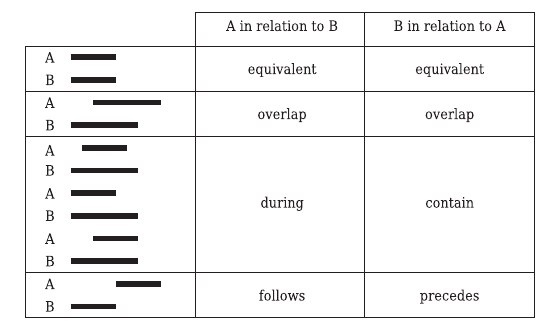

### TGRASS framework and workflow

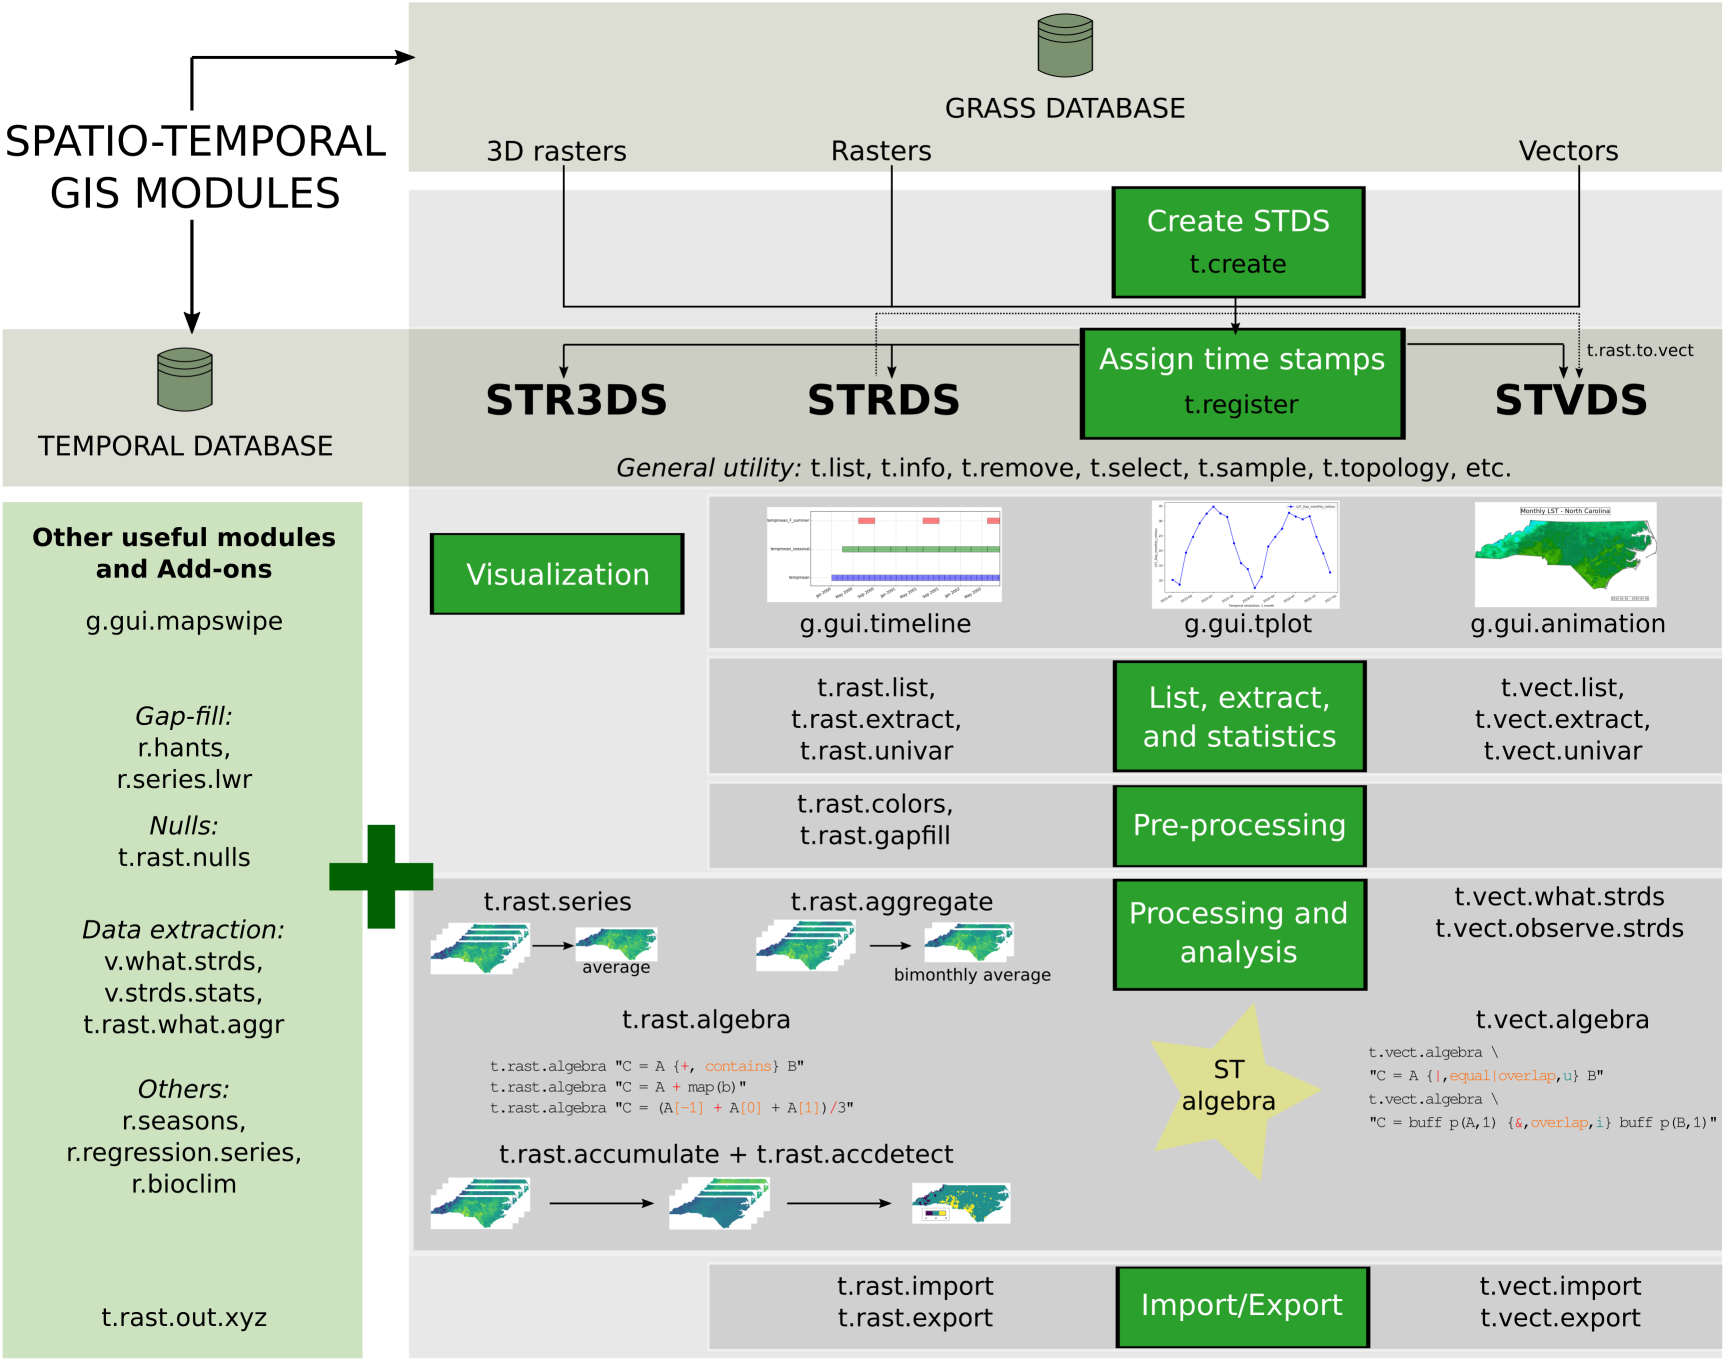

## GRASS + 

### `grass.script`

The **grass.script** or GRASS Python Scripting Library provides
functions for calling GRASS tools within Python scripts. The most
commonly used functions include:

-   `run_command`: used when the output of the tools is a raster or
    vector, no text type output is expected
-   `read_command`: used when the output of the tools is of text type
-   `parse_command`: used with tools whose output can be converted to
    `key=value` pairs
-   `write_command`: used with tools that expect text input, either in
    the form of a file or from standard input

It also provides several wrapper functions for frequently used tools,
for example:

-   To get info from a raster: `gs.raster_info('dsm')`
-   To get info of a vector: `gs.vector_info('roads')`
-   To list the raster maps in a project:
    `gs.list_grouped(type=['raster'])`
-   To obtain the computational region: `gs.region()`

> **Note**
>
> More info:
> <https://grass.osgeo.org/grass-stable/manuals/libpython/script_intro.html>

### `grass.jupyter`

The **grass.jupyter** library improves the integration of GRASS and
Jupyter, and provides different classes to facilitate GRASS maps
visualization:

-   `init`: starts a GRASS session and sets up all necessary environment
    variables
-   `Map`: 2D rendering
-   `Map3D`: 3D rendering
-   `InteractiveMap`: interactive visualization with folium
-   `SeriesMap`: visualizations for a series of raster or vector maps
-   `TimeSeriesMap`: visualization for spatio-temporal data

> **Note**
>
> More info:
> <https://grass.osgeo.org/grass-stable/manuals/libpython/grass.jupyter.html>

## Start a GRASS session

To start a GRASS session, we need a project. For this workshop, a ready
to use project is provided and it is saved in your Google Drive inside
the `pavia_2026` folder. The session is then started with `gj.init()`.

In [8]:
# Start working session in the eu_laea project
project = 'eu_laea'
mapset = 'italy_LST_daily'
session = gj.init(dest, project, mapset)

> **Note**
>
> To create your own GRASS projects, use `gs.create_project()` function.
> Learn more about it
> [here](https://grass.osgeo.org/grass85/manuals/grass_projects.html?h=create_project#creating-grass-projects).

### Explore data in the mapset

Let’s first explore what we have within the `italy_LST_daily` mapset and
display vector and raster maps using different classes from
`grass.jupyter` library.

In [9]:
# List vector elements
gs.list_grouped(type="vector")['italy_LST_daily']

In [10]:
# Display vector map
it_map = gj.Map(width=500, use_region=True)
it_map.d_vect(map="italy_borders_0")
it_map.show()

In [11]:
# List raster elements
rast = gs.list_grouped(type="raster", pattern="lst*")['italy_LST_daily']
rast[0:10]

In [12]:
# Display raster map with interactive class
lst_map = gj.InteractiveMap(width = 500, use_region=True, tiles="OpenStreetMap")
lst_map.add_raster("lst_2014.005_avg")
lst_map.add_layer_control(position = "bottomright")
lst_map.show()

## SDM workflow

> **Note**
>
> Check <https://ecodiv.earth/TutorialsNotes/sdmingrassgis/> for a very
> detailed guide to Species Distribution models with MaxEnt in GRASS.
> Optianally, follow this
> [tutorial](https://veroandreo.github.io/grass_ncsu_2023/notebook_ex_sdm_r.html)
> if you are interested in using R for SDM.

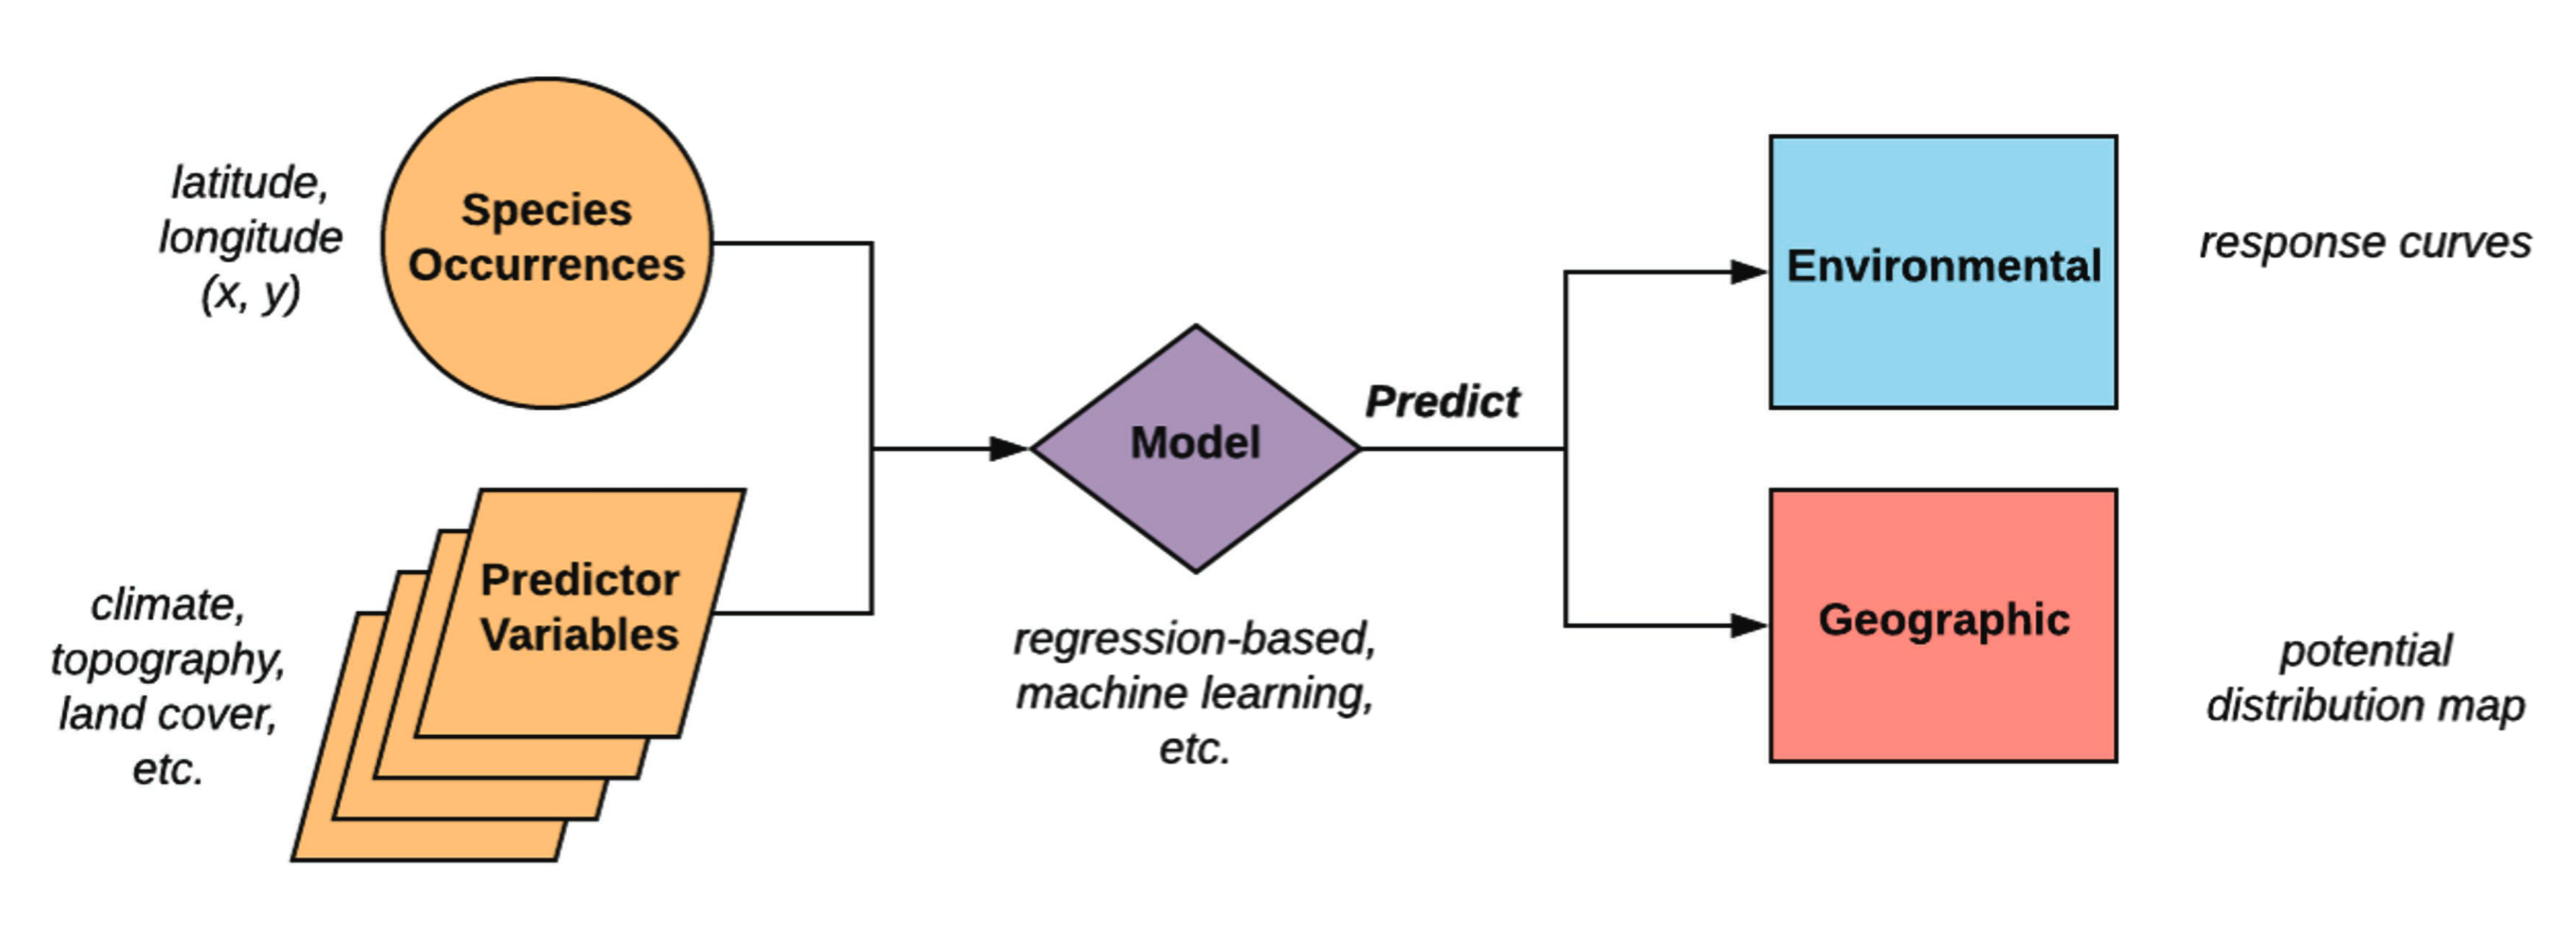

### Species and background data

#### Importing species records

We will use occurrence data already downloaded and cleaned. We need to
import it into GRASS first.

In [13]:
# Import mosquito records
gs.run_command("v.import",
               input=os.path.join(dest,"aedes_albopictus.gpkg"),
               output="aedes_albopictus")

Let’s add the occurrence points over the previous interactive map

In [14]:
# Display raster map with interactive class
lst_map = gj.InteractiveMap(width = 500, use_region=True, tiles="OpenStreetMap")
lst_map.add_raster("lst_2014.005_avg")
lst_map.add_vector("aedes_albopictus")
lst_map.add_layer_control(position = "bottomright")
lst_map.show()

You can also get the mosquito occurrences (or any other species or taxa)
directly from [GBIF](https://www.gbif.org/) into GRASS by means of
[v.in.pygbif](https://grass.osgeo.org/grass-stable/manuals/addons/v.in.pygbif.html)
addon, as follows:

In [15]:
# Set computational region
# region = gs.parse_command("g.region", raster="lst_2014.001_avg", flags="g")
# region

In [16]:
# Install extension (requires pygbif: pip install pygbif)
# gs.run_command("g.extension",
#                extension="v.in.pygbif")

In [17]:
# Import data from GBIF
# gs.run_command("v.in.pygbif", 
#                output="aedes_albopictus",
#                taxa="Aedes albopictus",
#                date_from="2014-01-01",
#                date_to="2025-12-31")

#### Creating random background points

The MaxEnt algorithm that we will use in the next part of this session
requires not only the points of known occurrences, but also information
on the rest of the environment available for the species. These are not
absences but background data, we actually do not know if the species is
there or not, but we need them to compare to the features of the places
where the species does occur.

To avoid getting background points exactly where occurrences are, we’ll
create buffers around them. Then, we need to ensure that background
points are only over land within our computational region. In order to
do that, we’ll create a mask over land and we’ll overlay the buffers
with the mask.

Can you guess what the output will be?

In [18]:
# Create buffer around Aedes albopictus records
gs.run_command("v.buffer",
               input="aedes_albopictus",
               output="aedes_buffer",
               distance=2000)

In [19]:
# Set computational region
region = gs.parse_command("g.region", raster="lst_2014.001_avg", flags="g")
region

In [20]:
# Create a vector mask to limit background points
expression="MASK = if(lst_2014.001_avg, 1, null())"
gs.raster.mapcalc(exp=expression)

gs.run_command("r.to.vect", 
               input="MASK",
               output="vect_mask",
               type="area")

In [21]:
# Subtract buffers from vector mask
gs.run_command("v.overlay",
               ainput="vect_mask",
               binput="aedes_buffer",
               operator="xor",
               output="mask_bg")

Let’s display the result

In [22]:
# Display raster map with interactive class
mask_map = gj.InteractiveMap(width = 500, use_region=True, tiles="OpenStreetMap")
mask_map.add_vector("mask_bg")
mask_map.add_layer_control(position = "bottomright")
mask_map.show()

Finally, let’s create the random background points…

In [23]:
# Generate random background points
gs.run_command("v.random",
               output="background_points",
               npoints=1000,
               restrict="mask_bg",
               seed=3749)

and display occurrence and background points together over an LST map.

In [24]:
# Display vector map
pb_map = gj.Map(width=500, use_region=True)
pb_map.d_rast(map="lst_2014.005_avg")
pb_map.d_vect(map="italy_borders_0", type="boundary")
pb_map.d_vect(map="background_points")
pb_map.d_vect(map="aedes_albopictus", icon="basic/diamond", fill_color="red", size=8)
pb_map.show()

### Predictors crafting

#### Create daily LST time series

Now we’ll start processing the raster data to derive potentially
relevant predictors to include in the model. Our data consists of a time
series of daily LST averages. We’ll use the GRASS temporal framework.
The first step is to create the time series object and register maps in
it. See
[t.create](https://grass.osgeo.org/grass-stable/manuals/t.create.html)
and
[t.register](https://grass.osgeo.org/grass-stable/manuals/t.register.html)
for further details.

In [25]:
# Create time series 
gs.run_command("t.create",
               type="strds",
               temporaltype="absolute",
               output="lst_daily",
               title="Average Daily LST",
               description="Average daily LST in degree C - 2014-2018")

In [26]:
# Check it is created
gs.run_command("t.list",
              type="strds")

In [27]:
# Get list of maps 
map_list = gs.list_grouped(type="raster", pattern="lst_201*")['italy_LST_daily']
map_list[0:10]

In [28]:
# Register maps in strds  
gs.run_command("t.register", 
               input="lst_daily",
               maps=map_list,
               increment="1 days",
               start="2014-01-01", 
               flags="i")

In [29]:
# Get info about the strds
gs.run_command("t.info",
               input="lst_daily")

Now that we created the time series or **STRDS**, let’s start estimating
relevant variables. We start by calculating long term aggregations, also
called *climatologies*.

#### Long term monthly avg, min and max LST

Let’s see an example first; we’ll estimate the average of all maps which
start date is within January.

In [30]:
# January average LST
gs.run_command("t.rast.series",
               input="lst_daily",
               method="average",
               where="strftime('%m', start_time)='01'",
               output="lst_average_jan")

In [31]:
# Get map info and check values
gs.raster_info("lst_average_jan")['min'], gs.raster_info("lst_average_jan")['max']

We want to estimate climatologies for all months, so let’s try first to
get the list of maps that will be the input for
[t.rast.series](https://grass.osgeo.org/grass-stable/manuals/t.rast.series.html).
We’ll test the condition in
[t.rast.list](https://grass.osgeo.org/grass-stable/manuals/t.rast.list.html)
first.

In [32]:
# Define list of months as required
months=['{0:02d}'.format(m) for m in range(1,13)]

for m in months:
    gs.run_command("t.rast.list",
                   input="lst_daily",
                   where=f"strftime('%m', start_time)='{m}'")

Now we add the `methods` and we are ready to estimate climatologies for
all months with three different methods.

In [33]:
# Now we estimate the climatologies for all months and methods
months=['{0:02d}'.format(m) for m in range(1,13)]
methods=["average","minimum","maximum"]

for m in months:
    for me in methods:
        gs.run_command("t.rast.series", 
                       input="lst_daily",
                       method=me,
                       where=f"strftime('%m', start_time)='{m}'",
                       output="lst_{}_{}".format(me,m))

In [34]:
# List newly created maps
map_list = gs.list_grouped(type="raster", pattern="*{average,minimum,maximum}*")['italy_LST_daily']
print(map_list)

In [35]:
# Remove lst_average_jan
gs.run_command("g.remove", type="raster", name="lst_average_jan", flags="f")

#### Bioclimatic variables

Perhaps you have heard of [Worldclim](https://www.worldclim.org/) or
[CHELSA](https://chelsa-climate.org/) bioclimatic variables? Well, these
are 19 variables that represent potentially limiting conditions for
species. They derive from the combination of temperature and
precipitation long term averages. As we do not have precipitation data
in this exercise, we’ll only estimate the bioclimatic variables that
include temperature. See
[r.bioclim](https://grass.osgeo.org/grass-stable/manuals/addons/r.bioclim.html)
manual for further details. Note that we’ll use the climatologies
estimated in the previous step.

In [36]:
# Install extension
gs.run_command("g.extension",
               extension="r.bioclim")

In [37]:
# Get lists of maps needed
tmin=gs.list_grouped(type="raster", pattern="lst_minimum_??")['italy_LST_daily']
tmax=gs.list_grouped(type="raster", pattern="lst_maximum_??")['italy_LST_daily']
tavg=gs.list_grouped(type="raster", pattern="lst_average_??")['italy_LST_daily']

print(tmin,tmax,tavg)

In [38]:
# Estimate temperature related bioclimatic variables
gs.run_command("r.bioclim", 
               tmin=tmin, 
               tmax=tmax,
               tavg=tavg, 
               output="bioclim_") 

In [39]:
# List output maps
gs.list_grouped(type="raster", pattern="bioclim*")['italy_LST_daily']

Let’s have a look at some of the maps we just created

In [40]:
# Display raster map with interactive class
bio_map = gj.InteractiveMap(width = 500, use_region=True, tiles="OpenStreetMap")
bio_map.add_raster("bioclim_bio01")
bio_map.add_raster("bioclim_bio02")
bio_map.add_layer_control(position = "bottomright")
bio_map.show()

#### Spring warming

We define spring warming as the velocity with which temperature
increases from winter into spring and we calculate it as
`slope(daily Tmean February-March-April)`. We will use
[t.rast.aggregate](https://grass.osgeo.org/grass-stable/manuals/t.rast.aggregate.html).

In [41]:
# Define list of months
months=['{0:02d}'.format(m) for m in range(2,5)]

In [42]:
# Annual spring warming
gs.run_command("t.rast.aggregate",
               input="lst_daily",
               output="annual_spring_warming",
               basename="spring_warming",
               suffix="gran",
               method="slope",
               granularity="1 years",
               where=f"strftime('%m',start_time)='{months[0]}' or strftime('%m',start_time)='{months[1]}' or strftime('%m', start_time)='{months[2]}'")

In [43]:
# Check raster maps in the STRDS
gs.run_command("t.rast.list", input="annual_spring_warming")

In [44]:
# Average spring warming
gs.run_command("t.rast.series",
               input="annual_spring_warming",
               output="avg_spring_warming",
               method="average")

In [45]:
# Display raster map with interactive class
auc_map = gj.InteractiveMap(width = 500, use_region=True, tiles="OpenStreetMap")
auc_map.add_raster("avg_spring_warming")
auc_map.add_layer_control(position = "bottomright")
auc_map.show()

#### Autumnal cooling

We define autumnal cooling as the velocity with which temperature
decreases from summer into fall and we calculate it as
`slope(daily Tmean August-September-October)`.

In [46]:
# Define list of months
months=['{0:02d}'.format(m) for m in range(8,11)]

In [47]:
# Annual autumnal cooling
gs.run_command("t.rast.aggregate",
               input="lst_daily",
               output="annual_autumnal_cooling",
               basename="autumnal_cooling",
               suffix="gran",
               method="slope",
               granularity="1 years",
               where=f"strftime('%m',start_time)='{months[0]}' or strftime('%m',start_time)='{months[1]}' or strftime('%m', start_time)='{months[2]}'")

In [48]:
# Check raster maps in the STRDS
gs.run_command("t.rast.list", input="annual_autumnal_cooling")

In [49]:
# Average autumnal cooling
gs.run_command("t.rast.series",
               input="annual_autumnal_cooling",
               output="avg_autumnal_cooling",
               method="average")

In [50]:
# Display raster map with interactive class
spw_map = gj.InteractiveMap(width = 500, use_region=True, tiles="OpenStreetMap")
spw_map.add_raster("avg_autumnal_cooling")
spw_map.add_layer_control(position = "bottomright")
spw_map.show()

#### Number of days with LSTmean \>= 25 and \<= 30

Mosquitoes (and viruses they might carry) tend to thrive in a certain
range of temperatures. Let’s assume this range is from 25 to 30 °C.
Here, we’ll estimate the number of days within this range per year, and
then, we’ll estimate the average along years. See
[t.rast.algebra](https://grass.osgeo.org/grass-stable/manuals/t.rast.algebra.html)
manual for further details.

In [51]:
# Keep only pixels meeting the condition
expression="tmean_higher25_lower30 = if(lst_daily >= 25.0 && lst_daily <= 30.0, 1, null())"

gs.run_command("t.rast.algebra",
               expression=expression, 
               basename="tmean_higher25_lower30",
               suffix="gran",
               nproc=7, 
               flags="n")

In [52]:
# Count how many times per year the condition is met
gs.run_command("t.rast.aggregate",
               input="tmean_higher25_lower30", 
               output="count_tmean_higher25_lower30",
               basename="tmean_higher25_lower30",
               suffix="gran",
               method="count",
               granularity="1 years")

In [53]:
# Check raster maps in the STRDS
gs.run_command("t.rast.list", 
               input="count_tmean_higher25_lower30", 
               columns="name,start_time,min,max")

In [54]:
# Average number of days with LSTmean >= 20 and <= 30
gs.run_command("t.rast.series",
               input="count_tmean_higher25_lower30",
               output="avg_count_tmean_higher25_lower30",
               method="average")

In [55]:
# Display raster map with interactive class
h20_map = gj.InteractiveMap(width = 500, use_region=True, tiles="OpenStreetMap")
h20_map.add_raster("avg_count_tmean_higher25_lower30")
h20_map.add_layer_control(position = "bottomright")
h20_map.show()

#### Number of days with LSTmin \<= 10.0

Likewise, there are temperature thresholds that mark a limit to mosquito
survival. Here, we’ll use the temperature lower limit to survival and
count the number of days with temperatures below this threshold.

In [56]:
# Keep only pixels meeting the condition
expression="tmean_lower10 = if(lst_daily <= 10.0, 1, null())"

gs.run_command("t.rast.algebra",
               expression=expression, 
               basename="tmean_lower10",
               suffix="gran",
               nproc=7, 
               flags="n")

In [57]:
# Count how many times per year the condition is met
gs.run_command("t.rast.aggregate",
               input="tmean_lower10", 
               output="count_tmean_lower10",
               basename="tmean_lower10",
               suffix="gran",
               method="count",
               granularity="1 years")

In [58]:
# Check raster maps in the STRDS
gs.run_command("t.rast.list", 
               input="count_tmean_lower10", 
               columns="name,start_time,min,max")

In [59]:
# Median number of days with LSTmean <= 10
gs.run_command("t.rast.series",
               input="count_tmean_lower10",
               output="median_count_tmean_lower10",
               method="median")

In [60]:
# Display raster map with interactive class
h20_map = gj.InteractiveMap(width = 500, use_region=True, tiles="OpenStreetMap")
h20_map.add_raster("median_count_tmean_lower10")
h20_map.add_layer_control(position = "bottomright")
h20_map.show()

We have now derived many potentially relevant predictors for the
mosquito habitat suitability and we could still derive some more, for
example, the number of mosquito or virus cycles per year based on
development temperature thresholds and growing degree days (GDD). This
could be achieved with
[t.rast.accumulate](https://grass.osgeo.org/grass-stable/manuals/t.rast.accumulate.html)
and
[t.rast.accdetect](https://grass.osgeo.org/grass-stable/manuals/t.rast.accdetect.html).
See an example at the time series accumulation
[tutorial](https://grass-tutorials.osgeo.org/content/tutorials/time_series/time_series_accumulations.html).

### Modeling

#### Install required addons

We need a set of GRASS addons to run the SDM workflow. Install them once
per session.

In [61]:
addons = [
    "r.maxent.setup",   # configure MaxEnt jar
    "r.maxent.train",   # train MaxEnt model
    "r.maxent.predict", # predict from lambdas file
    "v.maxent.swd",     # export occurrence + background in SWD format
    "r.vif",            # variance inflation factor for variable selection
]
for addon in addons:
    gs.run_command("g.extension", extension=addon)

MaxEnt requires a Java runtime (that we already installed) and the
`maxent.jar` file. Point GRASS to both:

In [62]:
# Set path to maxent.jar
gs.run_command("r.maxent.setup",
               maxent=os.path.join(dest, "maxent/maxent.jar"))

# Verify Java is reachable
gs.run_command("r.maxent.setup", flags="j")

### Variable selection

Before training, we remove redundant predictors using the Variance
Inflation Factor (VIF). We keep variables with VIF \< 10.

In [63]:
# Collect all candidate predictor maps
predictors = gs.list_grouped(
    type="raster",
    pattern="bioclim_bio*,avg_spring_warming,avg_autumnal_cooling,"
            "avg_count_tmean_higher25_lower30,median_count_tmean_lower10"
)['italy_LST_daily']

print(predictors)

In [64]:
# Run VIF — iteratively removes the most collinear variable until all VIF < 10
gs.run_command("r.vif",
               maps=predictors,
               n=100000,
               maxvif=10,
               seed=42)

> **Note**
>
> Note the selected variables printed by `r.vif` and update
> `selected_vars` below.

In [65]:
# Update this list with the variables retained by r.vif
selected_vars = [
    "bioclim_bio01",
    "bioclim_bio04",
    "bioclim_bio05",
    "bioclim_bio06",
    "avg_spring_warming",
    "avg_autumnal_cooling",
    "avg_count_tmean_higher25_lower30",
    "median_count_tmean_lower10",
]

### Export data for MaxEnt (SWD format)

`v.maxent.swd` extracts the predictor values at occurrence and
background locations and exports them in the *Samples With Data* (SWD)
format that MaxEnt expects. It also exports ASCII rasters of the
predictors.

In [66]:
os.makedirs(os.path.join(dest, "model_input/swd"), exist_ok=True)
os.makedirs(os.path.join(dest, "model_input/ascii"), exist_ok=True)

gs.run_command(
    "v.maxent.swd",
    flags="t",
    species="aedes_albopictus",
    bgp="background_points",
    evp_maps=",".join(selected_vars),
    species_output=os.path.join(dest, "model_input/swd/species.swd"),
    bgr_output=os.path.join(dest, "model_input/swd/background.swd"),
    export_rasters=os.path.join(dest, "model_input/ascii"),
)

### Train MaxEnt model with cross-validation

We run 4-fold cross-validation to assess model performance. MaxEnt will
iteratively hold out one fold as test data and train on the remaining
three.

In [67]:
os.makedirs(os.path.join(dest, "model_02"), exist_ok=True)

gs.run_command(
    "r.maxent.train",
    flags="ybg",
    samplesfile=os.path.join(dest, "model_input/swd/species.swd"),
    environmentallayersfile=os.path.join(dest, "model_input/swd/background.swd"),
    projectionlayers=os.path.join(dest, "model_input/ascii"),
    outputdirectory=os.path.join(dest, "model_cv"),
    replicatetype="crossvalidate",
    replicates=4,
    samplepredictions="modelcv_suitability_occurrences",
    backgroundpredictions="modelcv_suitability_background",
    predictionlayer="modelcv_suitability",
    threads=2,
    memory=1000,
)

Let’s visualise the result:

In [68]:
sdm_map = gj.InteractiveMap(width=500, use_region=True, tiles="OpenStreetMap")
sdm_map.add_raster("modelcv_suitability")
sdm_map.add_vector("aedes_albopictus")
sdm_map.add_layer_control(position="bottomright")
sdm_map.show()

> **Note**
>
> Open the HTML report in `model_02/` to inspect the mean test AUC
> across folds, variable importance (% contribution and permutation
> importance), and response curves.

In [69]:
# Inspect prediction variability across folds at occurrence locations
gs.run_command(
    "v.colors",
    map="modelcv_suitability_occurrences",
    use="attr",
    column="Cloglog_range",
    color="bcyr",
)

sdm_cv_map = gj.InteractiveMap(width=500, use_region=True, tiles="OpenStreetMap")
sdm_cv_map.add_raster("modelcv_suitability_mean")
sdm_cv_map.add_vector("modelcv_suitability_occurrences")
sdm_cv_map.add_layer_control(position="bottomright")
sdm_cv_map.show()

#### Presence-absence maps

Convert the continuous suitability map to a binary presence/absence map
using a 0.5 threshold:

In [70]:
gs.run_command(
    "r.mapcalc",
    expression="modelcv_presence = if(model01_suitability >= 0.5, 1, 0)",
)

gs.run_command("r.colors", map="modelcv_presence", color="ndvi")

In [71]:
pa_map = gj.InteractiveMap(width=500, use_region=True, tiles="OpenStreetMap")
pa_map.add_raster("modelcv_presence")
pa_map.add_vector("aedes_albopictus")
pa_map.add_layer_control(position="bottomright")
pa_map.show()

### Predict species distribution in other areas or time periods

We can re-predict from the lambdas file. This is useful for applying the
model to different environmental scenarios:

In [72]:
# DO NOT RUN

# gs.run_command(
#     "r.maxent.predict",
#     lambdafile=os.path.join(dest, "model_cv/aedes_albopictus.lambdas"),
#     rasters=",".join(selected_vars), # future version of present vars
#     output="modelcv_suitability_future",
# )

### Disclaimer

This is only a simple example for doing SDM and only the beginning…
There are several other steps or pathways we may follow:

-   presence records thinning
-   other types of models
-   variable selection according to importance
-   hyper-parameter tuning
-   evaluation with independent data
-   ensemble modeling
-   uncertainty assessment and extrapolation analysis
-   projection on new data, transfer the model to other areas or periods

Also, if you are interested on how a similar workflow can be achieved
within R, calling maps we stored in GRASS, check this optional notebook:
[SDM training with R](notebook-03.qmd).